In [1]:
from segment import SegModel
import numpy as np
import matplotlib.pyplot as plt 
from skimage.filters import sobel
from skimage.morphology import area_opening, binary_dilation
from pathlib import Path
import shutil
from tqdm.notebook import tqdm
import torch

data_root = Path("Cell data/full raw dataset")

In [2]:

def seg_preprocess(img):
    im = np.zeros((2, img.shape[1], img.shape[2]), dtype=np.float32)
    im[0] = (lambda x: ((x - x.min())/(x.max() - x.min()))if (x.max() - x.min()) >= 100 else x/(2.0**16-1))(img[0])
    
    #im[1] = (lambda x: ((x - x.min())/(x.max() - x.min())))(sobel(img[1]))
    im[1] = (lambda x: ((x - x.min())/(x.max() - x.min()))if (x.max() - x.min()) >= 100 else x/(2.0**16-1))(sobel(img[2]))
    return im

def toRGB(img):
    im = np.zeros((img.shape[1], img.shape[2], 3))
    im[:, :, 0] = img[0]
    im[:, :, 1] = img[1]
    #im[:, :, 1] = img[2]
    return im

In [15]:
segment = SegModel("model-550-BCE.pth", post_processing=lambda x: binary_dilation(binary_dilation(area_opening(x))), 
                   device=torch.device("mps"))

for i in range(4):
    datas = list(data_root.joinpath("raw_kill_{}".format(i)).glob("*.npy"))
    for data in tqdm(datas, desc="in forder raw_kill_{}".format(i)):
        if data.stem[-3:] == "seg":
            continue
        frames = np.load(data)
        if (frames.shape[-1] == 3):
            frames = np.transpose(frames, axes=(0, 3, 1, 2))
        preds = []
        for frame in frames:
            #frame = frame.transpose(2, 0, 1)
            # only for new data
            # frame = frame[(0, 2), :, :]
            pred, _ = segment.segment(seg_preprocess(frame))
            preds.append(pred)
        preds = np.array(preds)
        if (preds.shape[1] != preds.shape[2]):
            print("looks like wrong shape, frames: {}, preds: {}".format(frames.shape, preds.shape))
            raise ValueError
        np.save(data.parent.joinpath("{}_seg.npy".format(data.stem)), preds)

in forder raw_kill_0:   0%|          | 0/3920 [00:00<?, ?it/s]

in forder raw_kill_1:   0%|          | 0/3340 [00:00<?, ?it/s]

in forder raw_kill_2:   0%|          | 0/2500 [00:00<?, ?it/s]

in forder raw_kill_3:   0%|          | 0/3193 [00:00<?, ?it/s]

(30, 120, 120)

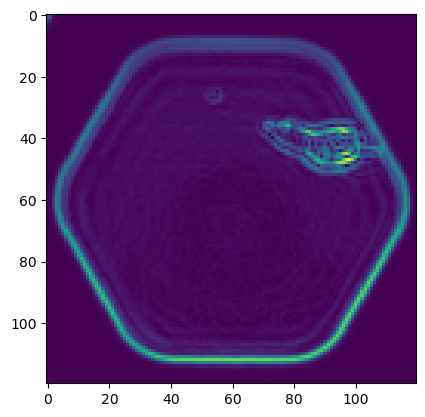

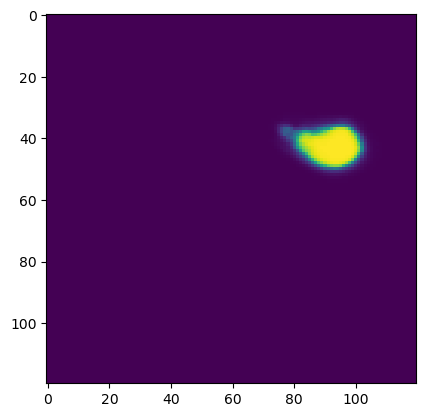

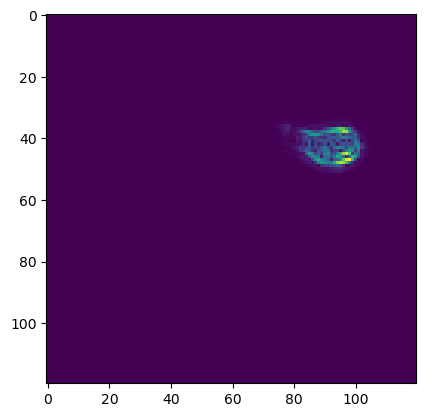

In [17]:
j =29
im = toRGB(seg_preprocess(frames[j]))
pred = preds[j]
plt.imshow(im[:,:,1])
plt.figure()
plt.imshow(pred)
plt.figure()
plt.imshow(im[:, :, 1]*pred)

preds.shape

In [ ]:
j = 29
im = frames[j]

plt.imshow(im[2])

